# Simple Plant Inspection Station DES 

In [363]:
import random
import numpy as np
import pandas as pd


In [364]:
def generate_flights(num_flights, num_consignment_per_flight, num_items_per_consignment):
    """Generate a list of cargo flights with consignments and item flags."""
    
    commodity_types = [
        "Fruits",
        "Vegetables",
        "Flower Cuttings",
    ]
    
    flights = []
    
    for i in range(num_flights):
        flight = {
            'flight_number': f'Flight-{i+1}',
            'origin': random.choice(["HKG", "FRA", "AMS", "DOH", "DXB", "ICN"]),
            'aircraft': random.choice(["B777F", "B747-8F", "A330F", "MD-11F"]),
            'consignments': []
        }
        
        for j in range(num_consignment_per_flight):
            consignment = {
                'consignment_number': f'Consignment-{j+1}',
                'commodity_type': random.choice(commodity_types),
                'items': [random.choices([True, False], weights=[2, 95])[0] for _ in range(num_items_per_consignment)]
            }
            flight['consignments'].append(consignment)
        
        flights.append(flight)
    
    return flights

# Example usage
flight_data = generate_flights(num_flights=3, num_consignment_per_flight=5, num_items_per_consignment=10)
flight_data

[{'flight_number': 'Flight-1',
  'origin': 'HKG',
  'aircraft': 'B777F',
  'consignments': [{'consignment_number': 'Consignment-1',
    'commodity_type': 'Flower Cuttings',
    'items': [False,
     False,
     False,
     False,
     False,
     False,
     False,
     False,
     False,
     True]},
   {'consignment_number': 'Consignment-2',
    'commodity_type': 'Fruits',
    'items': [False,
     False,
     False,
     False,
     False,
     False,
     False,
     False,
     False,
     False]},
   {'consignment_number': 'Consignment-3',
    'commodity_type': 'Flower Cuttings',
    'items': [False,
     False,
     False,
     False,
     False,
     False,
     False,
     False,
     False,
     False]},
   {'consignment_number': 'Consignment-4',
    'commodity_type': 'Flower Cuttings',
    'items': [False,
     False,
     False,
     False,
     False,
     False,
     False,
     False,
     False,
     False]},
   {'consignment_number': 'Consignment-5',
    'commodity_typ

In [365]:
def check_flagged_items(flights_data):
    """Returns a summary of flagged items (True) for each flight and consignment."""
    summary = []

    for flight in flights_data:
        flight_number = flight['flight_number']
        for consignment in flight['consignments']:
            consignment_number = consignment['consignment_number']
            flagged_count = sum(consignment['items'])
            summary.append({
                'flight_number': flight_number,
                'consignment_number': consignment_number,
                'flagged_items': flagged_count
            })
    
    return pd.DataFrame(summary)

check_flagged_items(flight_data)

,flight_number,consignment_number,flagged_items
0,Flight-1,Consignment-1,1
1,Flight-1,Consignment-2,0
2,Flight-1,Consignment-3,0
3,Flight-1,Consignment-4,0
4,Flight-1,Consignment-5,0
5,Flight-2,Consignment-1,0
6,Flight-2,Consignment-2,1
7,Flight-2,Consignment-3,0
8,Flight-2,Consignment-4,1
9,Flight-2,Consignment-5,0


In [366]:
class PlantInspectionStation(object):
    def __init__(self, parm_dict):
        self.num_items_inpsect = parm_dict['NUMBER_OF_ITEMS_INSPECTED']
        self.hypergeo_table = parm_dict['HYPERGEOMETRIC_DATA']

    def select_shipment(self, flight):
        """Decide whether a flight is selected inspection """
        inspect_shipment = random.choices([True, False], weights=[1,10])[0]
        flight_num = flight['flight_number'] 

        """ Print """
        if inspect_shipment:
            print(f"{flight_num} selected for inspection.")
        else:
            print(f"{flight_num} not selected for inspection.")
        
        return inspect_shipment

    def sample_consignment(self, flight):
        """ Select one consignment for inspection. """
        selected_consignment = random.choice(flight['consignments'])

        """ Print """
        consign_num = selected_consignment["consignment_number"]
        print(f"{consign_num} selected for inspection.")

        return selected_consignment
  
    def sample_inspect_items(self, selected_consignment):
        """Sample and inpsect items for inspection."""
        consign_num = selected_consignment["consignment_number"]
        
        """ Select the number of items based on policy or contraints """
        num_sample = self.get_sample_size(self.num_items_inpsect)
        selected_items = random.sample(selected_consignment["items"], k=min(num_sample, len(selected_consignment["items"])))
        
        """ Log number of detected infested items """
        num_infested_items = sum(selected_items)

        """ Print """
        if num_infested_items > 0:
            print(f"{num_infested_items} Pests detected in {consign_num}")
        else:
            print(f"No pests detected in {consign_num}")
        
        return num_infested_items


    def action_taken(self, num_infested_items):
        """ Decide whether to take action """
        if num_infested_items > 0:
            print(f"Action taken")
            action_taken = True
        else:
            print(f"No Action")
            action_taken = False

        return action_taken
    
    def get_sample_size(self, num_boxes):
        """ Use Hypergeometric Table to Decide Sample Size """
        for _, row in self.hypergeo_table.iterrows():
            if row["Minimum Number of Boxes"] <= num_boxes <= row["Maximum Number of Boxes"]:
                return row["Randomly select this number of boxes"]
        raise ValueError("Box count is out of range")


    def process_shipment(self, flight):
        """ Run function for processing each shipment """

        """ Decide whether a flight is selected inspection """
        inspect_shipment = self.select_shipment(flight)

        if inspect_shipment:
            """ Inpsect flight shipment that are selected for inspection """
            selected_consignment = self.sample_consignment(flight)
            num_infested_items = self.sample_inspect_items(selected_consignment)
            action_taken = self.action_taken(num_infested_items)

        else:
            """ No action taken if flight shipment is not selected for inpsection """
            action_taken = False

        return action_taken


In [367]:
RANDOM_SEED = 42
NUM_INSPECTORS = 5          # Minutes it takes to clean a car
NUM_FLIGHTS = 1000            # Number of flights to simulate
SIM_TIME = 20               # Simulation time in minutes

""" Define Parameters """

parms = {
    "NUMBER_OF_ITEMS_INSPECTED" : 5,
    "FLIGHTS_INTERARRIVAL" : 2,
    "HYPERGEOMETRIC_DATA" : pd.read_csv("data\hypergeometric_table.csv")
}

""" Create Simulation Routine """
def run_simulation(parm_dict):
    """ Unpack Model Parameters """
    flight_interarrival = parm_dict["FLIGHTS_INTERARRIVAL"]    # Time between flights in hours
    

    """ Setup Simulation """
    clock = 0
    arrival_times = []
    action_log = []

    """ Create Flight Schedules """
    flights_Dulles = generate_flights(NUM_FLIGHTS, 3, 5) 
    
    """ Construct PIS Model Class """
    PIS_Dulles = PlantInspectionStation(parm_dict)


    """ Run Simulation for One PIS """
    for flight in flights_Dulles:
        """ Adavnce Time """
        inter_arrival_time = np.random.exponential(1/flight_interarrival)
        clock += inter_arrival_time

        """ Process a single flight """
        flight_id = flight["flight_number"]
        print(f"{flight_id} arrived at {clock} hours.")
        action_taken = PIS_Dulles.process_shipment(flight)
        
        """ Report results for flight """
        arrival_times.append(clock)
        action_log.append(action_taken)

    """ Assemble results """
    results = {
        "Number of Actions" : sum(action_log),
        "Number of Flights" : len(flights_Dulles),
        "Action Log" : action_log,
        "Arrival Times" : arrival_times,
        "Flight Data" : flights_Dulles,

    }
    
    return results 


results = run_simulation(parms)

Flight-1 arrived at 1.4194486317167136 hours.
Flight-1 not selected for inspection.
Flight-2 arrived at 1.4817864833752548 hours.
Flight-2 not selected for inspection.
Flight-3 arrived at 3.004146351545036 hours.
Flight-3 not selected for inspection.
Flight-4 arrived at 4.304364936832783 hours.
Flight-4 not selected for inspection.
Flight-5 arrived at 4.569644688856191 hours.
Flight-5 not selected for inspection.
Flight-6 arrived at 4.585562876100968 hours.
Flight-6 not selected for inspection.
Flight-7 arrived at 6.145845548964704 hours.
Flight-7 not selected for inspection.
Flight-8 arrived at 7.027264376907262 hours.
Flight-8 not selected for inspection.
Flight-9 arrived at 7.823354200581403 hours.
Flight-9 not selected for inspection.
Flight-10 arrived at 7.949322244649651 hours.
Flight-10 not selected for inspection.
Flight-11 arrived at 7.989561400809038 hours.
Flight-11 not selected for inspection.
Flight-12 arrived at 8.077963581176139 hours.
Flight-12 not selected for inspecti

In [368]:
import matplotlib.pyplot as plt

def PlotActionSeries(results):
    # Data
    action_log = results["Action Log"]
    arrival_times = results["Arrival Times"]

    # Convert boolean to int for plotting
    action_log_numeric = [1 if action else 0 for action in action_log]

    # Plot
    plt.figure(figsize=(8, 4))
    plt.scatter(arrival_times, action_log_numeric, c=action_log_numeric, cmap='coolwarm', edgecolor='k')
    plt.yticks([0, 1], ['No Action', 'Action'])
    plt.xlabel('Arrival Time')
    plt.ylabel('Action Log')
    plt.title('Arrival Times vs Action Log')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


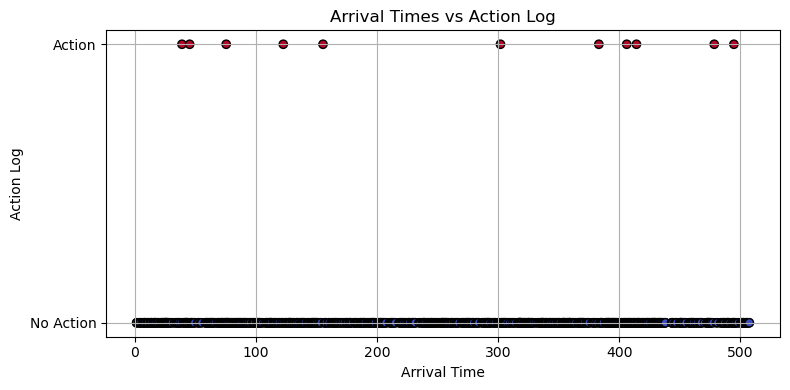

In [369]:
PlotActionSeries(results)

In [370]:
flagged_summary_df = check_flagged_items(results["Flight Data"])
flights_with_flags = flagged_summary_df.groupby("flight_number")["flagged_items"].sum()
flights_with_flags = flights_with_flags[flights_with_flags > 0]

# Total number of flights with flagged items
num_flights_with_flags = flights_with_flags.count()
num_flights_with_flags

270

In [371]:
sum(results["Action Log"]) / num_flights_with_flags

0.040740740740740744